In [49]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.units import units
import metpy.calc as mpcalc
import numpy as np
import imageio
import os
from scipy.ndimage import gaussian_filter



Hesaplama Tamam: Ug bileşeni max hızı 763.42 pascal / second


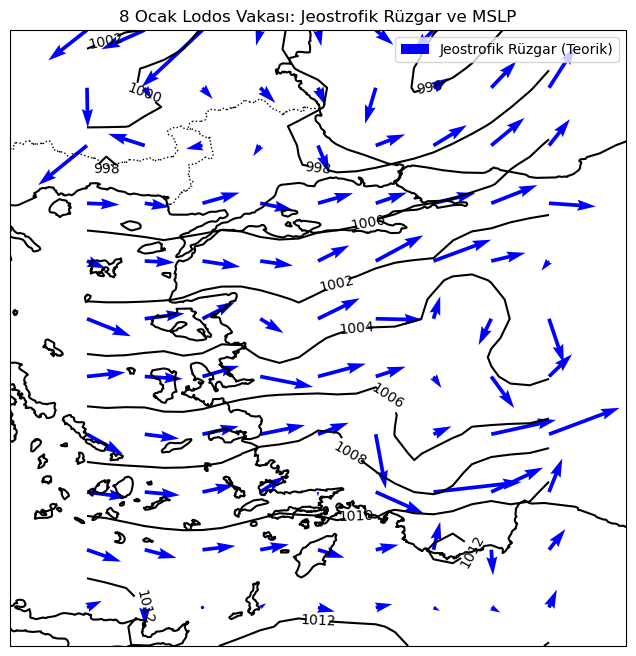

In [ ]:
# izobar üretimi

ds = xr.open_dataset('data/era5_lodos_vaka.nc')
data = ds.metpy.parse_cf()
mslp = ds.msl.metpy.unit_array
lats = ds.latitude
lons = ds.longitude
dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
vaka_saati = data.sel(valid_time='2026-01-08T12:00:00', method='nearest')
mslp_vaka = vaka_saati['msl']

ug, vg = mpcalc.geostrophic_wind(mslp_vaka)

print(f"Hesaplama Tamam: Ug bileşeni max hızı {ug.max():.2f}")
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

clevs = np.arange(980, 1040, 2) 
contours = ax.contour(lons, lats, mslp_vaka.values/100, levels=clevs, colors='black')
plt.clabel(contours, inline=True, fontsize=10, fmt='%i')

skip = 3
ax.quiver(lons[::skip], lats[::skip], 
          ug[::skip, ::skip].values, 
          vg[::skip, ::skip].values, 
          color='blue', label='Jeostrofik Rüzgar (Teorik)',
          transform=ccrs.PlateCarree())

ax.set_extent([24, 32, 35, 43]) 
plt.title('8 Ocak Lodos Vakası: Jeostrofik Rüzgar ve MSLP')
plt.legend()
plt.show()

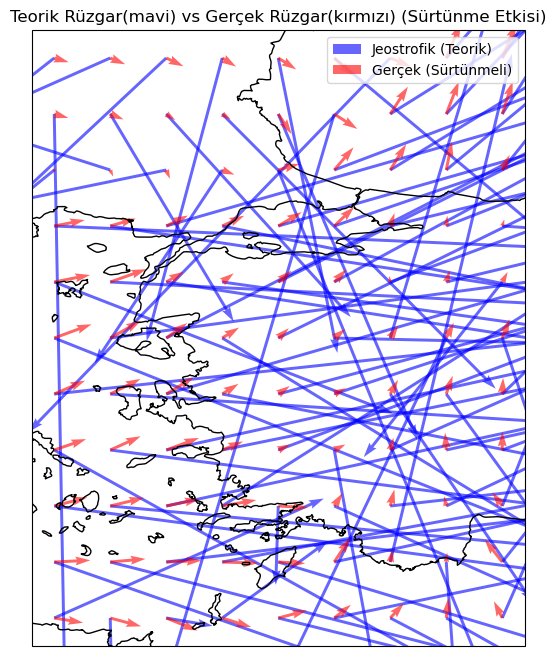

In [51]:
#---------------
# Gercek Rüzgar vs Jeostrofik rüzgar karşılaştırılması
#---------------
u_real = vaka_saati['u10']
v_real = vaka_saati['v10']

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)

# 1. Teorik Rüzgar (Mavi)
ax.quiver(lons[::skip], lats[::skip], ug[::skip, ::skip].values, vg[::skip, ::skip].values, 
          color='blue', alpha=0.6, label='Jeostrofik (Teorik)', scale=200)

# 2. Gerçek Rüzgar (Kırmızı)
ax.quiver(lons[::skip], lats[::skip], u_real[::skip, ::skip].values, v_real[::skip, ::skip].values, 
          color='red', alpha=0.6, label='Gerçek (Sürtünmeli)', scale=200)

plt.legend()
plt.title('Teorik Rüzgar(mavi) vs Gerçek Rüzgar(kırmızı) (Sürtünme Etkisi)')
plt.show()

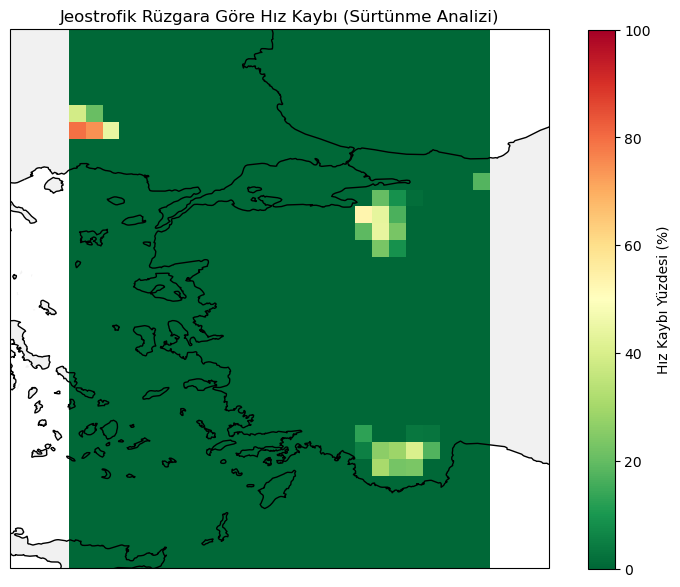

Gerçek Rüzgar Ortalaması: 9.175517082214355
Jeostrofik Rüzgar Ortalaması: 2.426795943246692


In [52]:
#---------
#Jeostrofik Rüzgara Göre Hız Kaybı
#----------------------------------
mslp_hpa = vaka_saati['msl'] / 100.0

mslp_hpa.attrs['units'] = 'hPa'
mslp_hpa = mslp_hpa.metpy.quantify()

ug, vg = mpcalc.geostrophic_wind(mslp_hpa)

ug_val = ug.values
vg_val = vg.values
ur_val = vaka_saati['u10'].values
vr_val = vaka_saati['v10'].values
ua = ur_val - ug.values
va = vr_val - vg.values

# Ageostrofik rüzgar hızı
speed_ageostrophic = np.sqrt(ua**2 + va**2)
speed_geostrophic = np.sqrt(ug_val**2 + vg_val**2)
speed_real = np.sqrt(ur_val**2 + vr_val**2)

speed_loss = (speed_geostrophic - speed_real) / (speed_geostrophic + 1e-6) * 100

angle_geostrophic = np.degrees(np.arctan2(vg_val, ug_val))
angle_real = np.degrees(np.arctan2(vr_val, ur_val))

angle_deviation = angle_geostrophic - angle_real
angle_deviation = (angle_deviation + 180) % 360 - 180
plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

mesh = ax.pcolormesh(lons, lats, speed_loss, cmap='RdYlGn_r', vmin=0, vmax=100)
plt.colorbar(mesh, label='Hız Kaybı Yüzdesi (%)')

ax.set_extent([24, 32, 35, 43])
plt.title('Jeostrofik Rüzgara Göre Hız Kaybı (Sürtünme Analizi)')
plt.show()
print(f"Gerçek Rüzgar Ortalaması: {speed_real.mean()}")
print(f"Jeostrofik Rüzgar Ortalaması: {speed_geostrophic.mean()}")


In [53]:
angle_deviation_xr = xr.DataArray(
    angle_deviation, 
    coords=[lats, lons], 
    dims=["latitude", "longitude"]
)

marmara_sapma = angle_deviation_xr.sel(latitude=slice(41, 40), longitude=slice(27, 29)).mean().values
ege_sapma = angle_deviation_xr.sel(latitude=slice(39, 37), longitude=slice(25, 27)).mean().values

print(f"Marmara Ortalama Sapma Açısı: {marmara_sapma:.2f} derece")
print(f"Ege Ortalama Sapma Açısı: {ege_sapma:.2f} derece")


Marmara Ortalama Sapma Açısı: -27.22 derece
Ege Ortalama Sapma Açısı: -20.73 derece


8 Ocak Lodosunda Max Karışım Yüksekliği: 2808.04 metre


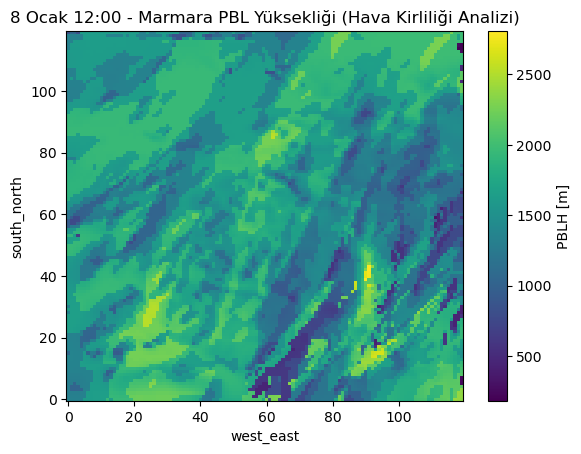

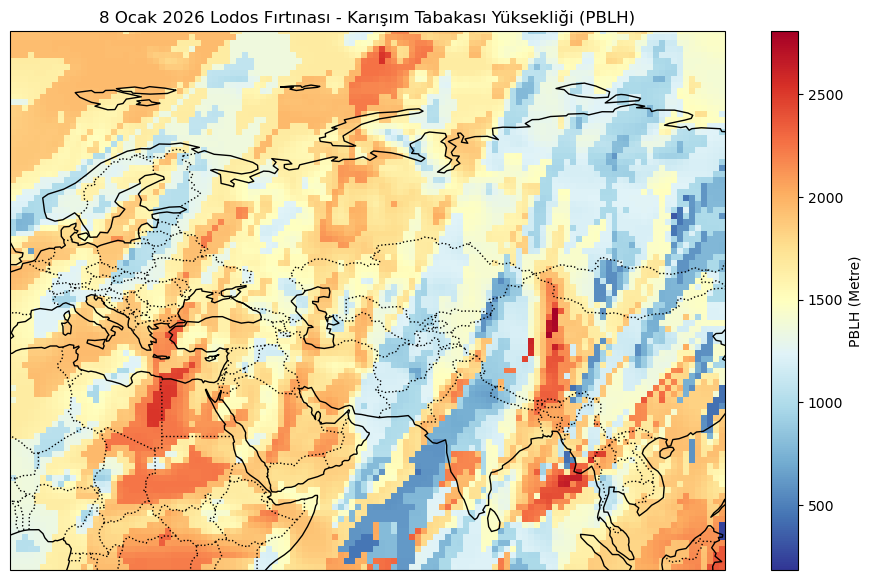

In [ ]:
# PBL (WRF veri)

file_path = "data/wrfout_d02_2026-01-08_12:00:00"
ds = xr.open_dataset(file_path,engine="netcdf4")
pblh = ds.PBLH[0, :, :]
print(f"8 Ocak Lodosunda Max Karışım Yüksekliği: {pblh.max().values:.2f} metre")

pblh.plot(cmap='viridis')
plt.title("8 Ocak 12:00 - Marmara PBL Yüksekliği (Hava Kirliliği Analizi)")
plt.show()

plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

pblh = ds.PBLH[0, :, :]
pblh_plot = pblh.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdYlBu_r', 
                      cbar_kwargs={'label': 'PBLH (Metre)'})

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
plt.title("8 Ocak 2026 Lodos Fırtınası - Karışım Tabakası Yüksekliği (PBLH)")
plt.show()


u10 = ds.U10[0, :, :]
v10 = ds.V10[0, :, :]
wspd = (u10**2 + v10**2)**0.5
wspd.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Spectral_r')

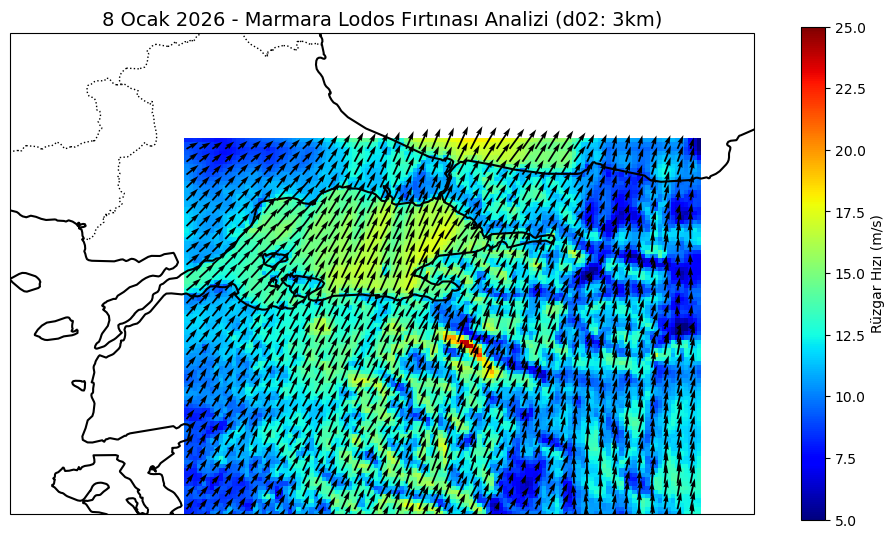

In [55]:
# Marmara Fırtına Analizi

lats = ds.XLAT[0, :, :]
lons = ds.XLONG[0, :, :]

plt.figure(figsize=(12, 8))
wrf_proj = ccrs.LambertConformal(
    central_longitude=ds.STAND_LON,
    central_latitude=ds.MOAD_CEN_LAT
)

ax = plt.axes(projection=wrf_proj)

cf = ax.pcolormesh(
    lons, lats, wspd,
    cmap='jet',
    vmin=5, vmax=25,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(cf, ax=ax, shrink=0.8)
cbar.set_label('Rüzgar Hızı (m/s)')
ax.quiver(
    lons[::skip, ::skip].values,
    lats[::skip, ::skip].values,
    u10[::skip, ::skip].values,
    v10[::skip, ::skip].values,
    transform=ccrs.PlateCarree(),
    color='black',
    scale=500
)
ax.set_extent([25.5, 31.5, 39.0, 42.0], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5) 


plt.title("8 Ocak 2026 - Marmara Lodos Fırtınası Analizi (d02: 3km)", fontsize=14)
plt.show()


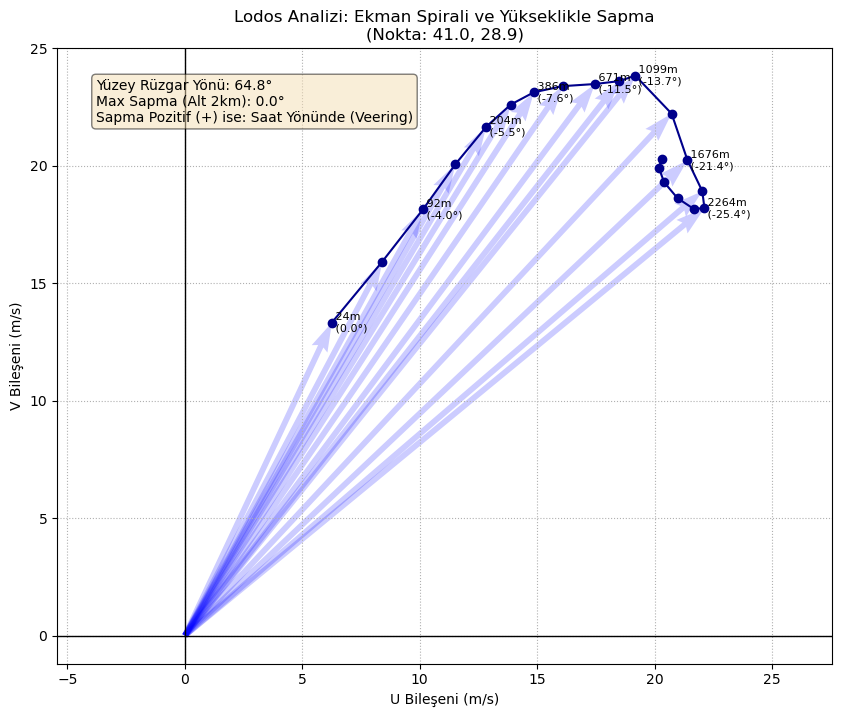

------------------------------
Yükseklik (m) | Sapma Açısı (Derece)
------------------------------
        24.3 |            0.00
        54.2 |           -2.67
        92.6 |           -4.04
       141.9 |           -4.70
       204.9 |           -5.48
       285.0 |           -6.38
       386.3 |           -7.56
       513.3 |           -9.35
       671.1 |          -11.47
       864.9 |          -12.93


In [56]:
# ----------------
# Ekman Spirali
#-------------------

target_lat, target_lon = 41.0, 28.9 
sq_diff = (ds.XLAT[0]-target_lat)**2 + (ds.XLONG[0]-target_lon)**2
lat_idx, lon_idx = np.unravel_index(sq_diff.argmin(), sq_diff.shape)

u_p = ds.U[0, :, lat_idx, lon_idx].values
v_p = ds.V[0, :, lat_idx, lon_idx].values

z_p = (ds.PH[0, :, lat_idx, lon_idx].values + ds.PHB[0, :, lat_idx, lon_idx].values) / 9.81
z_levels = z_p[:-1]


angles = np.degrees(np.arctan2(v_p, u_p))

surface_angle = angles[0]
relative_deviation = (angles - surface_angle + 180) % 360 - 180

fig, ax1 = plt.subplots(figsize=(10, 8))

ax1.plot(u_p[:20], v_p[:20], 'o-', color='darkblue', label='Rüzgar Vektör Uçları')
ax1.quiver(np.zeros(15), np.zeros(15), u_p[:15], v_p[:15], angles='xy', scale_units='xy', 
           scale=1, color='blue', alpha=0.2)

for i in range(0, 15, 2): 
    ax1.text(u_p[i], v_p[i], f' {int(z_levels[i])}m\n ({relative_deviation[i]:.1f}°)', 
             fontsize=8, verticalalignment='center')

ax1.set_xlabel('U Bileşeni (m/s)')
ax1.set_ylabel('V Bileşeni (m/s)')
ax1.set_title(f'Lodos Analizi: Ekman Spirali ve Yükseklikle Sapma\n(Nokta: {target_lat}, {target_lon})')
ax1.grid(True, linestyle=':')
ax1.axhline(0, color='black', lw=1)
ax1.axvline(0, color='black', lw=1)

textstr = '\n'.join((
    f'Yüzey Rüzgar Yönü: {surface_angle:.1f}°',
    f'Max Sapma (Alt 2km): {relative_deviation[:10].max():.1f}°',
    'Sapma Pozitif (+) ise: Saat Yönünde (Veering)'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.axis('equal')
plt.show()

print("-" * 30)
print("Yükseklik (m) | Sapma Açısı (Derece)")
print("-" * 30)
for i in range(10):
    print(f"{z_levels[i]:12.1f} | {relative_deviation[i]:15.2f}")

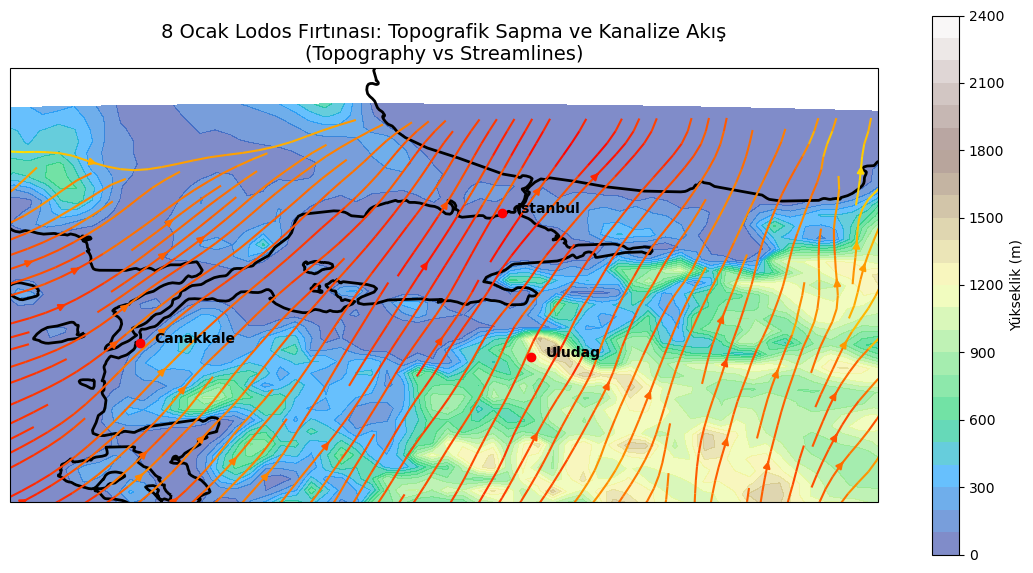

In [ ]:
# ----------------
# Topografik sapma
# ----------------------
file_path = "data/wrfout_d01_2026-01-08_12:00:00"
ds = xr.open_dataset(file_path,engine="netcdf4")

terrain = ds.HGT[0, :, :] 
u10 = ds.U10[0, :, :]
v10 = ds.V10[0, :, :]
lons = ds.XLONG[0, :, :]
lats = ds.XLAT[0, :, :]
 
wspd = np.sqrt(u10**2 + v10**2)
plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

levels = np.arange(0, 2500, 100)
terrain_plot = ax.contourf(lons, lats, terrain, levels=levels, cmap='terrain', alpha=0.6)
plt.colorbar(terrain_plot, label='Yükseklik (m)', shrink=0.7)

strm = ax.streamplot(lons.values, lats.values, u10.values, v10.values, 
                    color=wspd.values, cmap='autumn_r', linewidth=1.5, 
                    density=2, transform=ccrs.PlateCarree())


locations = {
    'Istanbul': [28.9, 41.0],
    'Canakkale': [26.4, 40.1],
    'Uludag': [29.1, 40.0]
}

for name, coords in locations.items():
    ax.plot(coords[0], coords[1], 'ro', transform=ccrs.PlateCarree())
    ax.text(coords[0]+0.1, coords[1], name, transform=ccrs.PlateCarree(), fontweight='bold')

ax.add_feature(cfeature.COASTLINE, linewidth=2)
ax.set_extent([25.5, 31.5, 39.0, 42.0]) # Marmara Odaklı

plt.title("8 Ocak Lodos Fırtınası: Topografik Sapma ve Kanalize Akış\n(Topography vs Streamlines)", fontsize=14)
plt.show()

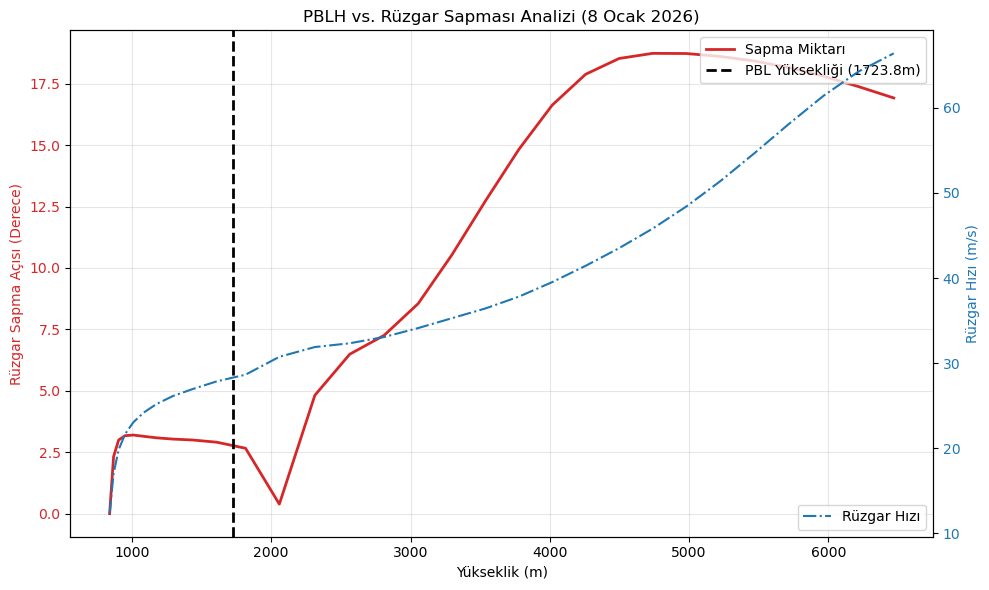

PBL İçindeki Ortalama Sapma: 2.69°
PBL Üstündeki Ortalama Sapma: 8.49°


In [ ]:
# ---------------
# PBHL vs Sapma
# ------------------
file_path = "data/wrfout_d02_2026-01-08_12:00:00"
ds = xr.open_dataset(file_path,engine="netcdf4")


lat_idx, lon_idx = 55, 65 
time_idx = 0
u = ds.U[time_idx, :, lat_idx, lon_idx].values
v = ds.V[time_idx, :, lat_idx, lon_idx].values
pblh_value = ds.PBLH[time_idx, lat_idx, lon_idx].values
z_heights = (ds.PH[time_idx, :, lat_idx, lon_idx].values + ds.PHB[time_idx, :, lat_idx, lon_idx].values) / 9.81
z_levels = z_heights[:-1] 

angles = np.degrees(np.arctan2(v, u))
surface_angle = angles[0]

deviations = np.abs((angles - surface_angle + 180) % 360 - 180)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Yükseklik (m)')
ax1.set_ylabel('Rüzgar Sapma Açısı (Derece)', color=color)
ax1.plot(z_levels[:30], deviations[:30], color=color, linewidth=2, label='Sapma Miktarı')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax1.axvline(x=pblh_value, color='black', linestyle='--', linewidth=2, 
            label=f'PBL Yüksekliği ({pblh_value:.1f}m)')

ax2 = ax1.twinx()
color = 'tab:blue'
wspd = np.sqrt(u**2 + v**2)
ax2.set_ylabel('Rüzgar Hızı (m/s)', color=color)
ax2.plot(z_levels[:30], wspd[:30], color=color, linestyle='-.', label='Rüzgar Hızı')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"PBLH vs. Rüzgar Sapması Analizi (8 Ocak 2026)")
fig.tight_layout()
ax1.legend(loc='upper right')
ax2.legend(loc='lower right')

plt.show()

pbl_top_idx = np.abs(z_levels - pblh_value).argmin()
print(f"PBL İçindeki Ortalama Sapma: {np.mean(deviations[:pbl_top_idx]):.2f}°")
print(f"PBL Üstündeki Ortalama Sapma: {np.mean(deviations[pbl_top_idx:pbl_top_idx+10]):.2f}°")

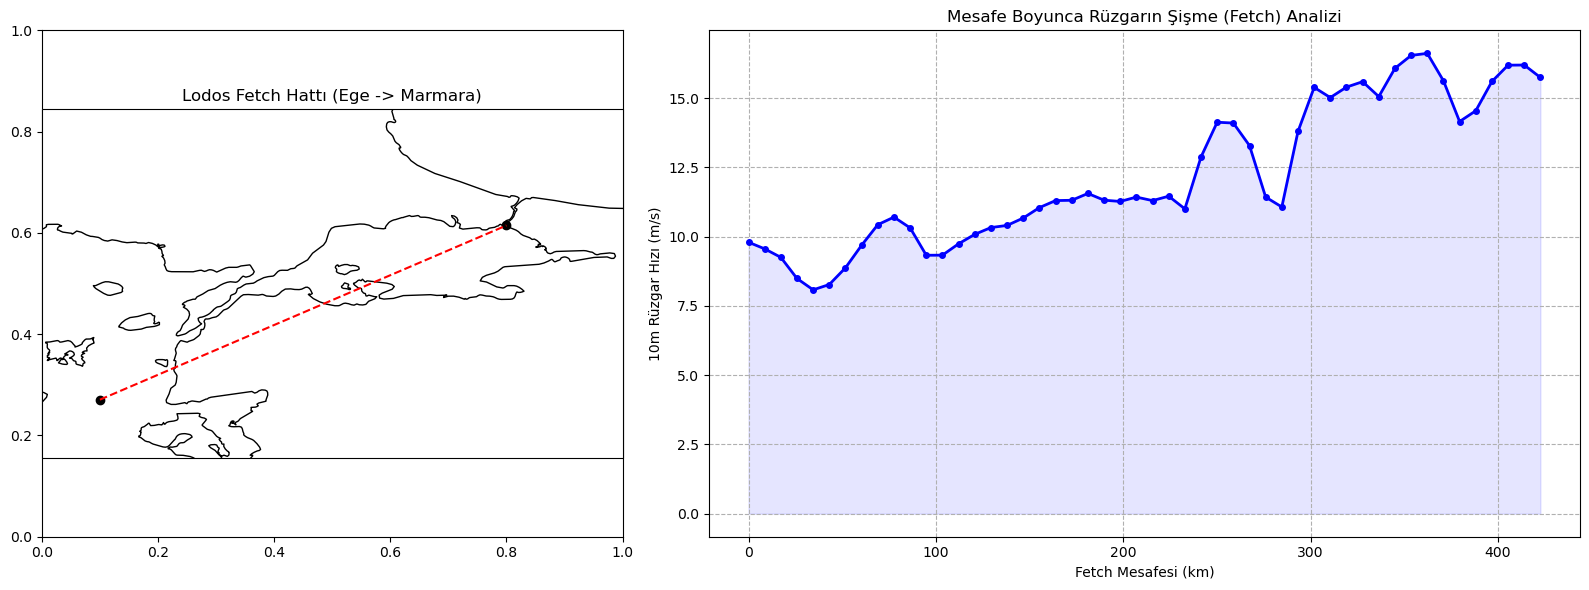

In [60]:
#--------------
#Wind Fetch
#-------------------
start_lat, start_lon = 39.5, 25.5
end_lat, end_lon = 41.0, 29.0

num_points = 50
lats_line = np.linspace(start_lat, end_lat, num_points)
lons_line = np.linspace(start_lon, end_lon, num_points)

wspd_all = np.sqrt(ds.U10[0]**2 + ds.V10[0]**2)
wspd_all = np.sqrt(ds.U10[0]**2 + ds.V10[0]**2).values 
lats_grid = ds.XLAT[0].values
lons_grid = ds.XLONG[0].values

fetch_wspd = []

for la, lo in zip(lats_line, lons_line):
   
    dist_sq = (lats_grid - la)**2 + (lons_grid - lo)**2
    
    y_idx, x_idx = np.unravel_index(np.argmin(dist_sq), dist_sq.shape)
    
    val = wspd_all[y_idx, x_idx]
    fetch_wspd.append(val)

dist = np.sqrt((lats_line - start_lat)**2 + (lons_line - start_lon)**2) * 111 # Yaklaşık km

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.5]})

ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_extent([25, 30, 39, 42])
ax1.plot(lons_line, lats_line, 'r--', transform=ccrs.PlateCarree(), label='Fetch Hattı (SW Flow)')
ax1.scatter([start_lon, end_lon], [start_lat, end_lat], color='black', transform=ccrs.PlateCarree())
ax1.set_title("Lodos Fetch Hattı (Ege -> Marmara)")

ax2.plot(dist, fetch_wspd, color='blue', marker='o', markersize=4, linewidth=2)
ax2.fill_between(dist, 0, fetch_wspd, color='blue', alpha=0.1)
ax2.set_xlabel('Fetch Mesafesi (km)')
ax2.set_ylabel('10m Rüzgar Hızı (m/s)')
ax2.set_title('Mesafe Boyunca Rüzgarın Şişme (Fetch) Analizi')
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

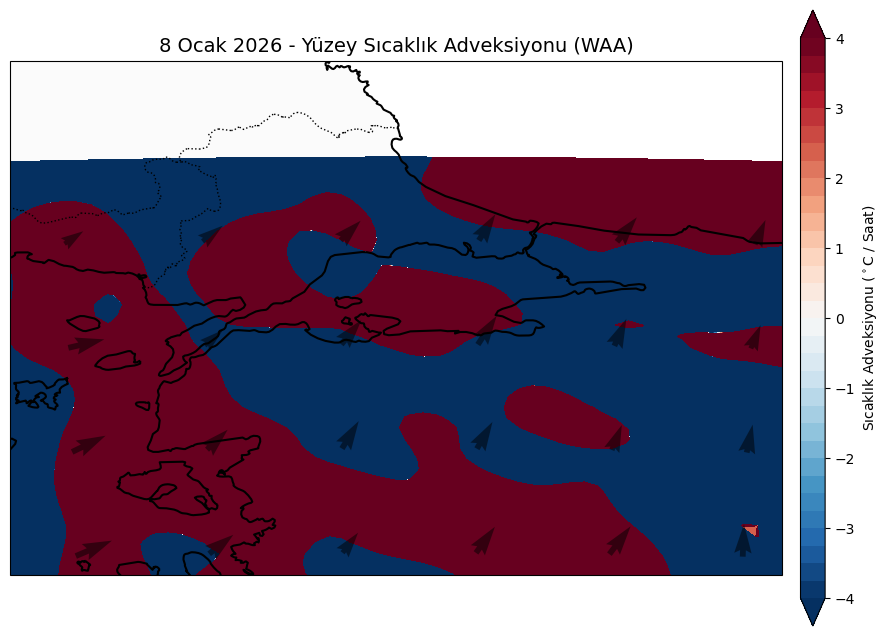

In [ ]:
#-----------
#Sıcak Adveksiyon
#-----------------------
file_path = "data/wrfout_d01_2026-01-08_12:00:00"
ds = xr.open_dataset(file_path,engine="netcdf4")

temp = ds.T2[0, :, :].values * units.kelvin
u = ds.U10[0, :, :].values * (units.m / units.s)
v = ds.V10[0, :, :].values * (units.m / units.s)
lats = ds.XLAT[0, :, :].values * units.degrees
lons = ds.XLONG[0, :, :].values * units.degrees

dx, dy = mpcalc.lat_lon_grid_deltas(lons, lats)
grad_t = mpcalc.gradient(temp, deltas=(dy, dx))
dT_dy, dT_dx = grad_t[0], grad_t[1]

advection = -(u * dT_dx + v * dT_dy)
adv_per_hour = (advection * 3600).to(units.kelvin / units.hour)

sigma_val = 2.0
adv_smoothed = gaussian_filter(adv_per_hour.m, sigma=sigma_val)

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
clevs = np.linspace(-4, 4, 33) 

cf = ax.contourf(lons, lats, adv_smoothed, levels=clevs, 
                 cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf, orientation='vertical', pad=0.02, aspect=25)
cbar.set_label('Sıcaklık Adveksiyonu ($^\circ$C / Saat)')

skip = 10
ax.quiver(lons[::skip, ::skip], lats[::skip, ::skip], 
          u[::skip, ::skip].m, v[::skip, ::skip].m, 
          color='black', scale=300, alpha=0.5, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='whitesmoke', alpha=0.4)

ax.set_extent([25.0, 31.0, 38.5, 42.5], crs=ccrs.PlateCarree())

plt.title("8 Ocak 2026 - Yüzey Sıcaklık Adveksiyonu (WAA)", fontsize=14)
plt.show()